# Rossmann Store Sales – EDA, Data Comparison & Feature Engineering

Dataset: `data-rossmann/train.csv` · `data-rossmann/store.csv`  
Original Kaggle competition: *Rossmann Store Sales* (forecast daily sales for 1 115 German drugstores)

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## Part 1 – Data Onboarding & EDA

### 1.1 Data Integration

We load `train.csv` (daily sales records) and `store.csv` (static store metadata) and merge them on the common key `Store`.

In [67]:
train = pd.read_csv('data-rossmann/train.csv', low_memory=False)
train['Date'] = pd.to_datetime(train['Date'], format='%Y-%m-%d')  # faster than parse_dates=
store = pd.read_csv('data-rossmann/store.csv')

# left-join: keep every sales row, attach store metadata
df = train.merge(store, on='Store', how='left')

print(f"train  : {train.shape[0]:>9,} rows × {train.shape[1]} cols")
print(f"store  : {store.shape[0]:>9,} rows × {store.shape[1]} cols")
print(f"merged : {df.shape[0]:>9,} rows × {df.shape[1]} cols")
df.head()

train  : 1,017,209 rows × 9 cols
store  :     1,115 rows × 10 cols
merged : 1,017,209 rows × 18 cols


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### 1.2 Missing Data Analysis – `CompetitionDistance`

In [68]:
missing_mask = df['CompetitionDistance'].isna()
n_missing = missing_mask.sum()
n_total = df.shape[0]
print(f"total rows                            : {n_total:,}")
print(f"Rows with missing CompetitionDistance : {n_missing}")
print(f"Affected store IDs                    : {sorted(df.loc[missing_mask, 'Store'].unique())}")
print()
print(df['CompetitionDistance'].describe())

total rows                            : 1,017,209
Rows with missing CompetitionDistance : 2642
Affected store IDs                    : [291, 622, 879]

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64


**What does a missing value in `CompetitionDistance` mean in this context?**

`CompetitionDistance` records the distance (in metres) to the nearest competitor store. A missing value most likely means that **no competitor has been identified in the vicinity** of that store — not that the measurement was simply overlooked.

**Which strategy makes sense here?**

| Option | Verdict |
|--------|--------|
| **Drop rows** | ⚠ Only 3 affected stores (~2 700 rows, 0.27 % of data) — statistically negligible, but semantically misleading: it implies those stores don't exist rather than that they have no competitor |
| **Fill with column mean/median** | ✗ Implies a competitor exists at an average distance — factually wrong |
| **Fill with a large constant (e.g. column max)** | ✓ Encodes the intended meaning: *"no known competitor nearby"* — preserves all rows and is interpretable |

We fill with the observed maximum distance. Dropping would also be defensible given the tiny share, but the fill strategy better reflects the business reality.

In [69]:
max_dist = df['CompetitionDistance'].max()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(max_dist)

print(f"Max distance used as fill : {max_dist:.0f} m")
print(f"Remaining nulls           : {df['CompetitionDistance'].isna().sum()}")

Max distance used as fill : 75860 m
Remaining nulls           : 0


### 1.3 Target Analysis – Distribution of `Sales`

We filter out closed days (`Open == 0`) because a store that is closed records `Sales = 0` by definition : ->including those would create an artificial spike at zero that has no business meaning.

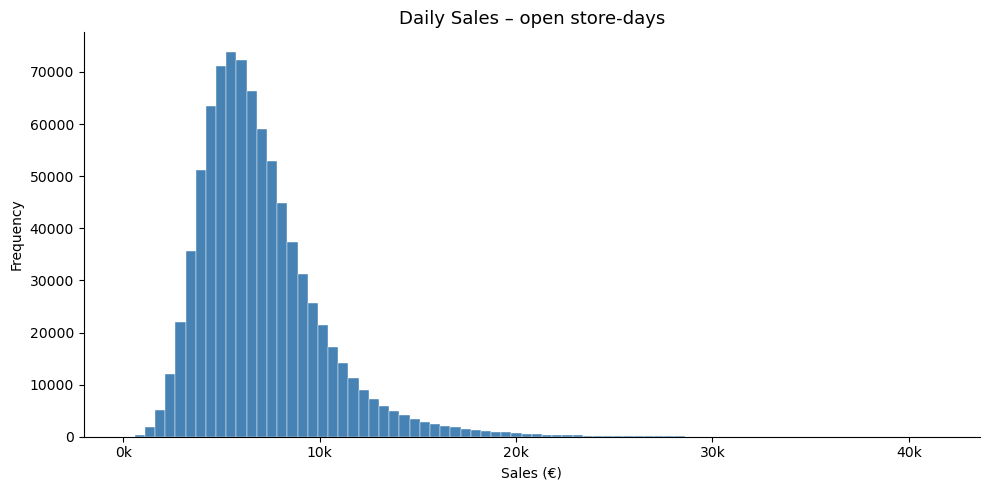

count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000


In [70]:
open_days = df[(df['Open'] == 1) & (df['Sales'] > 0)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(open_days['Sales'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('Daily Sales – open store-days', fontsize=13)
ax.set_xlabel('Sales (€)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

print(open_days['Sales'].describe().to_string())

**What do we notice about the distribution?**

The raw `Sales` distribution is **strongly right-skewed**: the bulk of days cluster between roughly €3 000 and €9 000, but a long right tail extends to €40 000+ (lookup max). This is characteristic of revenue data, which is bounded below at zero and occasionally sees very high-volume days (promotions, holidays).

---
## Part 2 – Comparing Data Structures

The Rossmann dataset differs from the Pittsburgh Car Survey and the Robot Degradation data in three key ways.

**Time dimension.** Rossmann has an explicit, regular time dimension one row per store per day. The Pittsburgh survey has no time dimension at all (each person appears only once). The robot data has a time dimension but at a fine-grained, irregular level (raw sensor signals rather than daily aggregates).

**Grouped structure.** Rossmann consists of 1 115 stores, each repeatedly measured over time so observations within the same store are not independent. The Pittsburgh survey has no groups (each person appears once). The robot data has no grouping either, as it tracks only a single machine.



---
## Part 3 – Feature Engineering

**Analytical question:**
> *"Does a store benefit long-term from running a continuous promotional campaign (Promo2), or is there only an initial 'hype' effect that fades after a few months, with sales returning to baseline?"*

---

### 3.1 Think & Justify

To answer this question, I need to know **how long a store has already been running Promo2 on each sales day**. Only then can I see whether sales stay elevated over time or drop back to normal after a few months.

The required quantities are:
1. The **start date** of Promo2 for each store (from `Promo2SinceWeek` + `Promo2SinceYear`)
2. The **months elapsed** since that start date for each row
3. **Average daily Sales** grouped by that elapsed time

In [71]:
# keep only Promo2 stores with valid start information
promo2_df = df[(df['Promo2'] == 1) & df['Promo2SinceWeek'].notna()].copy()

# construct the Promo2 start date from ISO week + year (Monday of that week)
promo2_df['Promo2Start'] = pd.to_datetime(
    promo2_df['Promo2SinceYear'].astype(int).astype(str)
    + '-W'
    + promo2_df['Promo2SinceWeek'].astype(int).astype(str).str.zfill(2)
    + '-1',
    format='%G-W%V-%u'
)

# elapsed months: approximate using 30.44 days / month
promo2_df['MonthsSincePromo2'] = (
    (promo2_df['Date'] - promo2_df['Promo2Start']).dt.days / 30.44
).astype(int)

# keep only rows after campaign start, within 36-month window, open days, non-zero sales
analysis = promo2_df[
    (promo2_df['MonthsSincePromo2'] >= 0)
    & (promo2_df['MonthsSincePromo2'] <= 36)
    & (promo2_df['Open'] == 1)
    & (promo2_df['Sales'] > 0)
].copy()

print(f"Promo2 stores in dataset : {promo2_df['Store'].nunique()}")
print(f"Rows used for analysis   : {len(analysis):,}")
analysis[['Date', 'Store', 'Sales', 'Promo2Start', 'MonthsSincePromo2']].head(8)

Promo2 stores in dataset : 571
Rows used for analysis   : 233,063


,Date,Store,Sales,Promo2Start,MonthsSincePromo2
19,2015-07-31,20,9593,2014-09-29,10
27,2015-07-31,28,7301,2015-02-02,5
29,2015-07-31,30,4776,2014-03-03,16
35,2015-07-31,36,12422,2014-09-29,10
38,2015-07-31,39,8336,2013-07-29,24
40,2015-07-31,41,6938,2013-07-29,24
46,2015-07-31,47,9379,2013-04-01,27
53,2015-07-31,54,10732,2013-01-28,30


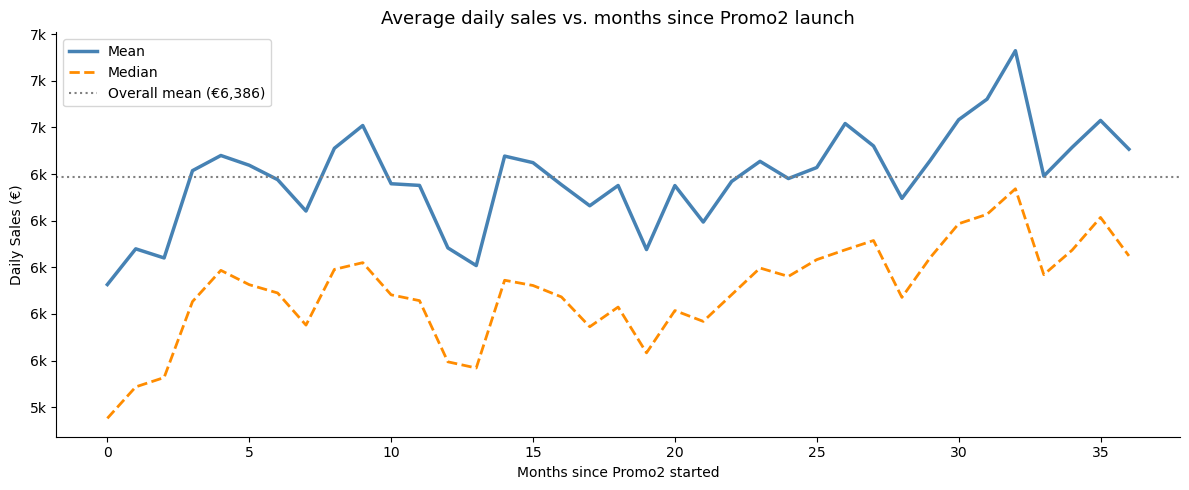

In [73]:
avg_by_month = (
    analysis
    .groupby('MonthsSincePromo2')['Sales']
    .agg(mean='mean', median='median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_by_month['MonthsSincePromo2'], avg_by_month['mean'],
        color='steelblue', lw=2.5, label='Mean')
ax.plot(avg_by_month['MonthsSincePromo2'], avg_by_month['median'],
        color='darkorange', lw=2, linestyle='--', label='Median')
ax.axhline(avg_by_month['mean'].mean(), color='gray', lw=1.5, linestyle=':',
           label=f'Overall mean (€{avg_by_month["mean"].mean():,.0f})')
ax.set_xlabel('Months since Promo2 started')
ax.set_ylabel('Daily Sales (€)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_title('Average daily sales vs. months since Promo2 launch', fontsize=13)
ax.legend()
plt.tight_layout()

plt.show()

### Answer to the Analytical Question

The plot shows that average sales stay broadly stable across all 36 months there is no spike at launch and no visible decline afterwards.

**Conclusion:** Promo2 appears to have a **durable effect** rather than a short-lived hype. Sales do not return to a lower baseline after the first few months.

**Caveat:** This is observational stores that joined Promo2 may already differ from stores that didn't, so we cannot prove causation. (correlation != causation)